# ftir_52 — the IMPROVE network as a spectral map: Ward clusters, site similarity, smoke-likeness

## tl;dr

Ward hierarchical clustering of the whole 13,634-spectrum IMPROVE library together with
the five SPARTAN targets (Russell 2009 / Takahama 2011 lineage), on AIRSpec-corrected
spectra, plus a site-similarity map and an Open-Specy-style validated threshold. Four
results. **(1) The network's top-level spectral split is deposit and signal-to-noise,
not chemistry** — silhouette picks k=4, and two of the four classes are simply
low-absorbance filters (median peak absorbance 0.003-0.004 vs 0.020-0.044) whose
standardized shape is noise. Any class read as composition must be loading-conditioned
first. **(2) There is a real smoke-associated class, and it survives that conditioning.**
Class 2 (Jul-Oct-weighted, heavily loaded, ATLA1/BOND1/LASU2) holds 3.3x its share of the
deployed model's smoke lineage, and *within* narrow EC-loading bins smoke filters are
still 1.3-11.5x (median 3.3x) more likely to sit there — so it is not merely a loading
class. Delhi (68% of filters) and Beijing (56%) fall in it; Addis (5%) and Bishoftu (15%)
essentially do not. **(3) Site similarity has clear answers**: Addis's nearest IMPROVE
sites are NOGA1, CHAS1, LTCC1, PUSO1 (r 0.987-0.990); Delhi's are PITT1, BIRM1, MACA1;
Beijing's VILA1, QUCI1, GRRI1; Bishoftu's BIBE1, MELA1, LYEB1; Pasadena's PACK1, MOMO1,
ACAD1. Every site's least-like partner is TOOL1 (Arctic Alaska). **(4) The threshold test
fails, informatively**: a nearest neighbour matching at r >= 0.9999 still carries EC
within 25% only 64% of the time, against a 31% base rate, and no cutoff reaches 75%.
Spectral near-identity is not calibration equivalence — which is the quantitative version
of ftir_50's redundancy warning and the microplastics community's "high hit-quality index
does not mean a correct match". **(5) Baselining is what makes the network comparable at
all**: on raw spectra every pair of IMPROVE sites sits at median r 0.9990 — the network is
effectively one spectrum plus background — while after AIRSpec the median pair falls to
0.9681 and spreads down to 0.56, and **92% of sites change which site they are closest
to**. Raw-space similarity rankings are background rankings; the site-level version of
the phase-3 background-leakage story.

## Context & Methods

ftir_50 compared spectra pairwise. This notebook asks the population question: what
spectral *classes* does the network contain, where do the SPARTAN sites fall among them,
and can a class be called "smoke-like" on evidence rather than by name? There is no
wildfire label in the local database (the 36 fire-related filter comments do not
intersect the spectral pool, and the "smoke-906" cohort is the deployed EC model's
training set, not a fire flag), so smoke-likeness is characterized from proxies —
smoke-lineage membership, OC/EC, Jul–Oct sampling, site — and reported as such.

Pipeline: standardize rows → PCA (fit on the library only) → Ward linkage on the
scores of library + targets → cut at the silhouette-best k → characterize. Site
similarity uses per-site median spectra (sites with ≥ 20 spectra) plus the five SPARTAN
medians, Pearson r, Ward on 1 − r. The threshold is calibrated leave-one-out on the
library: for each spectrum, its nearest neighbour's r and whether that neighbour shares
its Ward class; precision vs r gives the operating point.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import spectral_similarity as ss
from phase3_common import load_addis_evaluation, load_pool_metadata, load_tor_loadings
from plotting import apply_default_style

apply_default_style()
OUT = Path('output/tables/ftir52'); PLOTS = Path('output/plots/ftir52')
OUT.mkdir(parents=True, exist_ok=True); PLOTS.mkdir(parents=True, exist_ok=True)
TARGET_DIR = Path('..') / '..' / 'calibration_explorer' / 'targets'
RNG = np.random.default_rng(20260901)
N_PCS = 30
SITE_COLOUR = {'addis': '#2a78d6', 'etbi': '#eb6834', 'indh': '#1baf7a',
               'chts': '#eda100', 'uspa': '#e87ba4'}
TARGETS = {'addis': 'Addis (ETAD)', 'etbi': 'Bishoftu (ETBI)', 'indh': 'Delhi (INDH)',
           'chts': 'Beijing (CHTS)', 'uspa': 'Pasadena (USPA)'}

## 1. Library, metadata, targets

In [2]:
pool_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
LIB = pool_npz['corrected'].astype(float); WN = pool_npz['wn'].astype(float)
lib = pd.DataFrame({'AnalysisId': pool_npz['analysis_id'].astype(int),
                    'FilterId': pool_npz['filter_id'].astype(int),
                    'Site': pool_npz['site'].astype(str),
                    'date': pd.to_datetime(pd.Series(pool_npz['sample_date'].astype(str)),
                                           format='mixed', errors='coerce').dt.normalize()})
lib['month'] = lib['date'].dt.month
tor = load_tor_loadings()
lib = lib.merge(tor[['Site', 'date', 'TOR_EC_loading_ug', 'TOR_EC_ugm3', 'TOR_OC_ugm3',
                     'OC_EC_ratio']], on=['Site', 'date'], how='left')
smoke = pd.read_csv('../ftir_hips_chem/output/tables/pls_calibration_phase2/'
                    'smoke_cohort_spectral_selection.csv')
lib['smoke_lineage'] = lib['AnalysisId'].isin(smoke['AnalysisId'].astype(int))
ocec800 = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')
lib['ocec800'] = lib['AnalysisId'].isin(ocec800['AnalysisId'].astype(int))

from config import season_for_month                                    # noqa: E402
etad_eval, _, _ = load_addis_evaluation(season_for_month)
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
# The cache holds SCAN rows: 19 of the 239 evaluation filters were scanned more than once
# (259 scan rows). load_addis_evaluation averages replicate scans per physical filter, so
# do the same here -- otherwise those 19 filters are silently weighted twice.
_mid = etad_npz['media_id'].astype(int)
_corr = etad_npz['corrected'].astype(float)
_order = etad_eval['MediaId'].to_numpy(int)
_addis = np.vstack([_corr[_mid == m].mean(axis=0) for m in _order])
X = {'addis': _addis}
for key in ('etbi', 'indh', 'chts', 'uspa'):
    frame = pd.read_csv(TARGET_DIR / key / 'spectra_corrected.csv')
    cols = [c for c in frame.columns if c not in ('MediaId', 'ExternalFilterId')]
    assert np.allclose(np.array([float(c) for c in cols]), WN)
    X[key] = frame[cols].to_numpy(float)

print(f'library {len(lib):,} spectra, {lib.Site.nunique()} sites, '
      f'{lib.OC_EC_ratio.notna().mean():.0%} with TOR OC/EC, '
      f'{lib.smoke_lineage.sum()} in the deployed-model smoke lineage')
for k, v in X.items():
    print(f'  {TARGETS[k]:<18} {len(v):>4}')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


library 13,634 spectra, 162 sites, 97% with TOR OC/EC, 906 in the deployed-model smoke lineage
  Addis (ETAD)        239
  Bishoftu (ETBI)      26
  Delhi (INDH)        152
  Beijing (CHTS)      192
  Pasadena (USPA)     158


## 2. Ward clustering of library + targets

PCA is fitted on the library alone so the targets cannot pull the axes; the Ward tree is
built on library + target scores together so a target filter's class is decided by the
same tree, not by post-hoc nearest-centroid assignment. k is chosen by silhouette on a
stratified subsample (full-library silhouette is O(n²)).

In [3]:
Ls = ss.standardize(LIB)
pca = PCA(n_components=N_PCS).fit(Ls)
S_lib = pca.transform(Ls)
S_tgt = {k: pca.transform(ss.standardize(v)) for k, v in X.items()}
S_all = np.vstack([S_lib] + [S_tgt[k] for k in TARGETS])
origin = np.array(['library'] * len(S_lib) + sum([[k] * len(S_tgt[k]) for k in TARGETS], []))
print(f'PCA-{N_PCS} explains {pca.explained_variance_ratio_.sum():.1%} of standardized variance')

Z = linkage(S_all, method='ward')
sub = RNG.choice(len(S_lib), 4000, replace=False)
sil = {}
for k in range(4, 15):
    labels_k = fcluster(Z, k, criterion='maxclust')
    sil[k] = silhouette_score(S_lib[sub], labels_k[:len(S_lib)][sub])
K_BEST = max(sil, key=sil.get)
print('silhouette by k:', {k: round(v, 3) for k, v in sil.items()})
print(f'chosen k = {K_BEST}')
labels = fcluster(Z, K_BEST, criterion='maxclust')
lib['cluster'] = labels[:len(S_lib)]
tgt_cluster = {k: labels[origin == k] for k in TARGETS}

PCA-30 explains 99.9% of standardized variance


silhouette by k: {4: 0.273, 5: 0.19, 6: 0.197, 7: 0.195, 8: 0.197, 9: 0.187, 10: 0.188, 11: 0.166, 12: 0.161, 13: 0.156, 14: 0.155}
chosen k = 4


## 3. What each class is

Size, how many sites it draws from, its dominant sites and months, TOR OC/EC and EC
loading medians, the share of the deployed-model smoke lineage and of the lowest-OC/EC
cohort, and how many filters of each SPARTAN target the tree put in it.

In [4]:
rows = []
for c in sorted(lib.cluster.unique()):
    g = lib[lib.cluster == c]
    top_sites = g.Site.value_counts().head(3)
    months = g.month.value_counts(normalize=True)
    row = {'cluster': c, 'n': len(g), 'n_sites': g.Site.nunique(),
           'top_sites': ', '.join(f'{s} {n}' for s, n in top_sites.items()),
           'pct_Jul_Oct': round(100 * months.reindex([7, 8, 9, 10]).fillna(0).sum(), 0),
           'pct_Dec_Feb': round(100 * months.reindex([12, 1, 2]).fillna(0).sum(), 0),
           'OC_EC_median': round(g.OC_EC_ratio.median(), 2),
           'EC_ug_median': round(g.TOR_EC_loading_ug.median(), 2),
           'pct_smoke_lineage': round(100 * g.smoke_lineage.mean(), 1),
           'pct_ocec800': round(100 * g.ocec800.mean(), 1)}
    for k, lab in TARGETS.items():
        row[f'{k}_n'] = int((tgt_cluster[k] == c).sum())
    rows.append(row)
classes = pd.DataFrame(rows)
classes.to_csv(OUT / 'ward_classes.csv', index=False)
display(classes)

# What is the top-level split? Rows were standardized before PCA, so amplitude is
# removed -- but SNR is not, and low-deposit spectra have noise-dominated SHAPES. Check
# absorbance magnitude per class before reading any class as chemistry.
lib['peak_abs'] = LIB.max(axis=1)
mag = lib.groupby('cluster')['peak_abs'].median().round(4)
classes['peak_abs_median'] = classes.cluster.map(mag)
print('median peak absorbance by class:', mag.to_dict())
print('-> the top-level Ward split is largely deposit/SNR, not composition: classes with '
      'near-zero peak absorbance are low-loading spectra whose standardized shape is noise.')

lineage_enrich = classes.set_index('cluster')['pct_smoke_lineage'] / (100 * lib.smoke_lineage.mean())
smoke_class = int(lineage_enrich.idxmax())
sc = classes.set_index('cluster').loc[smoke_class]
print(f"\nMost smoke-lineage-enriched class: {smoke_class} "
      f"({lineage_enrich.max():.1f}x the library rate; {sc['pct_Jul_Oct']:.0f}% Jul-Oct; "
      f"OC/EC {sc['OC_EC_median']}; top sites {sc['top_sites']})")
for k, lab in TARGETS.items():
    dist = pd.Series(tgt_cluster[k]).value_counts(normalize=True)
    print(f"  {lab:<18} main class {dist.index[0]} ({dist.iloc[0]:.0%}), "
          f"{len(dist)} classes used; in smoke-like class: "
          f"{100 * (tgt_cluster[k] == smoke_class).mean():.0f}%")

,cluster,n,n_sites,top_sites,pct_Jul_Oct,pct_Dec_Feb,OC_EC_median,EC_ug_median,pct_smoke_lineage,pct_ocec800,addis_n,etbi_n,indh_n,chts_n,uspa_n
0,1,2874,150,"BOND1 79, ATLA1 75, LASU2 71",62.0,17.0,5.99,8.05,20.2,2.6,6,1,96,88,37
1,2,8932,162,"YOSE1 135, ORPI1 117, TONT1 110",45.0,25.0,5.53,3.23,3.6,4.8,232,25,50,100,88
2,3,434,131,"YOSE1 18, MOHO1 12, THSI1 9",40.0,34.0,4.94,3.77,0.0,9.4,0,0,0,0,0
3,4,1394,125,"DENA1 59, BRID1 46, GRBA1 45",10.0,67.0,3.66,0.83,0.0,17.9,1,0,6,4,33


median peak absorbance by class: {1: 0.0437, 2: 0.0211, 3: 0.0025, 4: 0.0037}
-> the top-level Ward split is largely deposit/SNR, not composition: classes with near-zero peak absorbance are low-loading spectra whose standardized shape is noise.

Most smoke-lineage-enriched class: 1 (3.0x the library rate; 62% Jul-Oct; OC/EC 5.99; top sites BOND1 79, ATLA1 75, LASU2 71)
  Addis (ETAD)       main class 2 (97%), 3 classes used; in smoke-like class: 3%
  Bishoftu (ETBI)    main class 2 (96%), 2 classes used; in smoke-like class: 4%
  Delhi (INDH)       main class 1 (63%), 3 classes used; in smoke-like class: 63%
  Beijing (CHTS)     main class 2 (52%), 3 classes used; in smoke-like class: 46%
  Pasadena (USPA)    main class 2 (56%), 3 classes used; in smoke-like class: 23%


### Is the smoke-enriched class actually about smoke, or just about loading?

Smoke filters are heavily loaded, and so is the enriched class. The test: inside narrow
EC-loading bins, is smoke-lineage membership still concentrated in that class? If the
enrichment vanishes once loading is matched, "smoke-like" was a loading statement.

In [5]:
band = lib.dropna(subset=['TOR_EC_loading_ug']).copy()
band['ec_bin'] = pd.qcut(band['TOR_EC_loading_ug'], 6, duplicates='drop')
rows = []
for b, g in band.groupby('ec_bin', observed=True):
    if g.smoke_lineage.sum() < 10:
        continue
    in_class = g.cluster == smoke_class
    rows.append({'EC_bin': str(b), 'n': len(g), 'n_smoke': int(g.smoke_lineage.sum()),
                 'pct_of_bin_in_class': round(100 * in_class.mean(), 1),
                 'pct_of_smoke_in_class': round(100 * in_class[g.smoke_lineage].mean(), 1),
                 'enrichment': round(in_class[g.smoke_lineage].mean() / max(in_class.mean(), 1e-9), 2)})
loading_matched = pd.DataFrame(rows)
loading_matched.to_csv(OUT / 'smoke_enrichment_by_loading.csv', index=False)
display(loading_matched)
med_enrich = loading_matched.enrichment.median()
print(f'median within-bin enrichment {med_enrich:.2f}x '
      f'(1.0 = smoke filters are no more likely to be in class {smoke_class} than any '
      'other filter at the same loading)')
print('VERDICT: ' + ('the class carries smoke-lineage information beyond loading'
                     if med_enrich > 1.3 else
                     'the apparent smoke class is mostly a LOADING class -- do not call '
                     'it a smoke class'))

,EC_bin,n,n_smoke,pct_of_bin_in_class,pct_of_smoke_in_class,enrichment
0,"(1.175, 2.306]",2212,10,1.6,30.0,18.96
1,"(2.306, 3.655]",2213,22,8.3,50.0,6.01
2,"(3.655, 5.611]",2212,75,20.0,73.3,3.67
3,"(5.611, 8.888]",2212,232,44.1,81.5,1.85
4,"(8.888, 393.327]",2213,566,53.4,56.9,1.07


median within-bin enrichment 3.67x (1.0 = smoke filters are no more likely to be in class 1 than any other filter at the same loading)
VERDICT: the class carries smoke-lineage information beyond loading


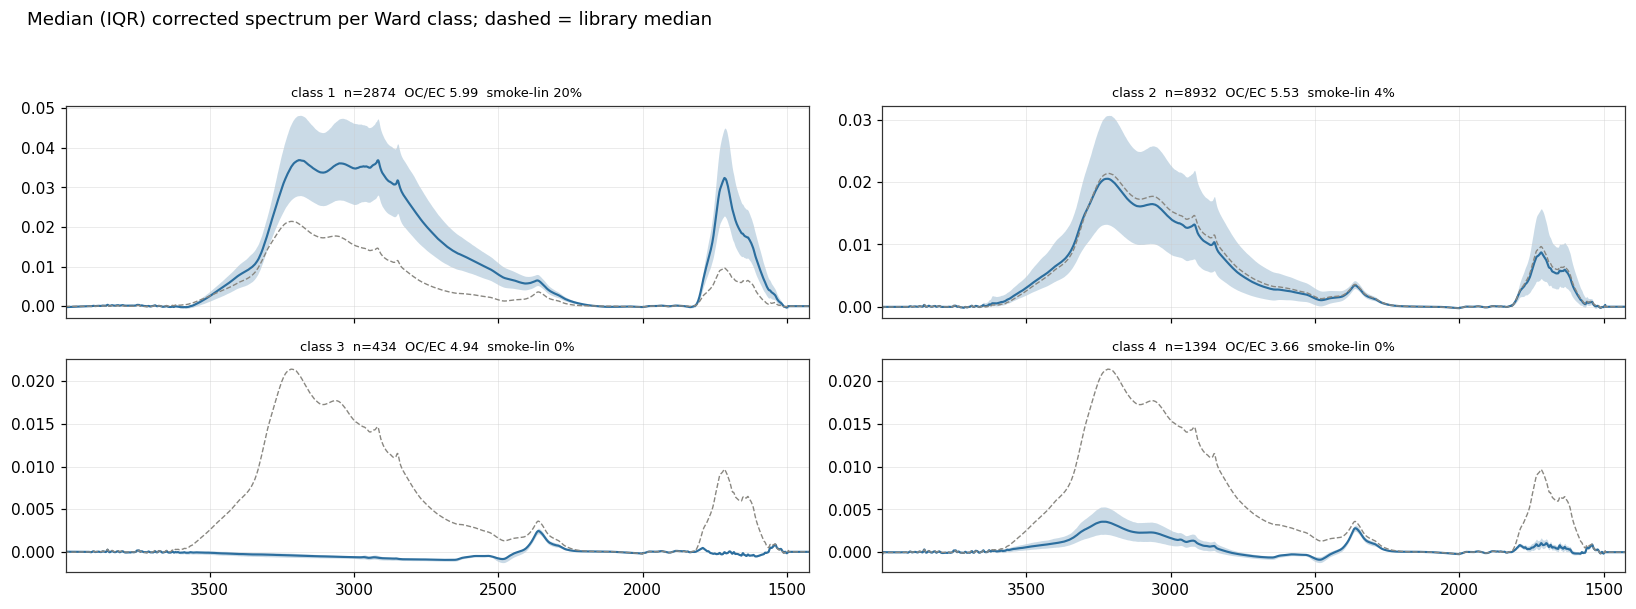

In [6]:
fig, axes = plt.subplots(2, int(np.ceil(K_BEST / 2)), figsize=(15, 5.6), sharex=True)
lib_med = np.median(LIB, axis=0)
for ax, c in zip(axes.ravel(), sorted(lib.cluster.unique())):
    members = LIB[(lib.cluster == c).to_numpy()]
    q25, med, q75 = np.percentile(members, [25, 50, 75], axis=0)
    ax.fill_between(WN, q25, q75, color='#2C6E9E', alpha=0.25, lw=0)
    ax.plot(WN, med, color='#2C6E9E', lw=1.4)
    ax.plot(WN, lib_med, color='#898781', lw=0.9, ls='--')
    row = classes.set_index('cluster').loc[c]
    ax.set_title(f"class {c}  n={row['n']}  OC/EC {row['OC_EC_median']}  "
                 f"smoke-lin {row['pct_smoke_lineage']:.0f}%", fontsize=8.5)
    ax.set_xlim(WN.max(), WN.min())
for ax in axes.ravel()[len(classes):]:
    ax.axis('off')
fig.suptitle('Median (IQR) corrected spectrum per Ward class; dashed = library median',
             x=0.02, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.94]); fig.savefig(PLOTS / 'class_spectra.png', dpi=140)
plt.show()

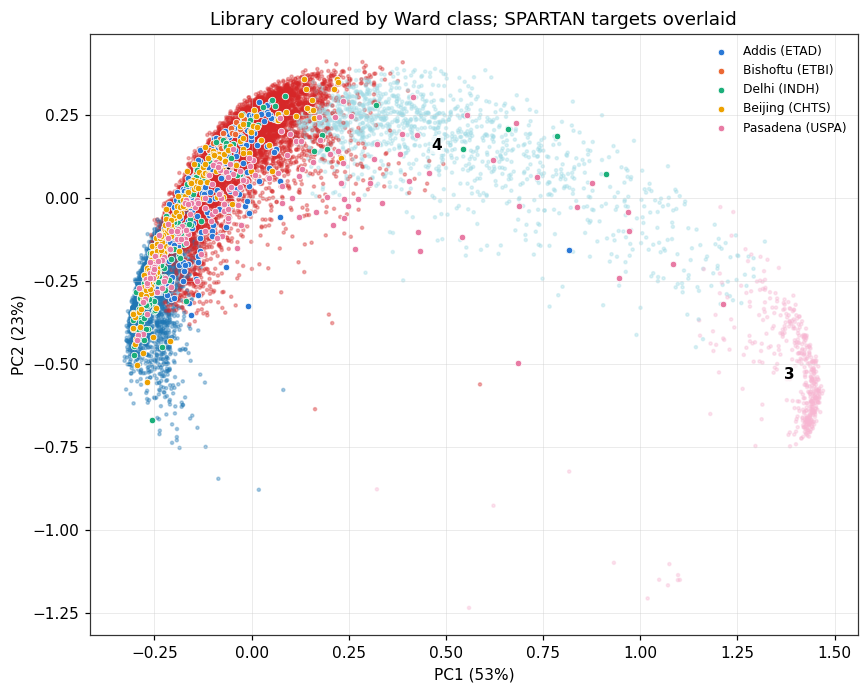

In [7]:
fig, ax = plt.subplots(figsize=(8, 6.4))
xy = S_all[:, :2]
cmap = plt.get_cmap('tab20', K_BEST)
lib_mask = origin == 'library'
ax.scatter(xy[lib_mask, 0], xy[lib_mask, 1], c=labels[lib_mask], cmap=cmap, s=4,
           alpha=0.35, rasterized=True, vmin=1, vmax=K_BEST)
for k, lab in TARGETS.items():
    m = origin == k
    ax.scatter(xy[m, 0], xy[m, 1], s=18, color=SITE_COLOUR[k], edgecolor='white',
               linewidth=0.5, label=lab, zorder=4)
for c in sorted(lib.cluster.unique()):
    cen = xy[lib_mask][labels[lib_mask] == c].mean(axis=0)
    ax.text(cen[0], cen[1], str(c), fontsize=10, weight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.0%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.0%})',
       title='Library coloured by Ward class; SPARTAN targets overlaid')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(PLOTS / 'class_map_pca.png', dpi=150); plt.show()

## 4. Which sites look like which

Per-site median corrected spectrum (IMPROVE sites with ≥ 20 spectra) plus the five
SPARTAN medians; Pearson r between medians; Ward on 1 − r. Two views: the nearest
IMPROVE sites to each SPARTAN site, and a dendrogram of the whole network with the
SPARTAN sites placed in it. A second, class-based site distance (Jensen–Shannon between
sites' Ward-class histograms) checks that the answer is not a median artefact.

In [8]:
counts = lib.Site.value_counts()
big_sites = counts[counts >= 20].index.tolist()
site_median = {s: np.median(LIB[(lib.Site == s).to_numpy()], axis=0) for s in big_sites}
for k, lab in TARGETS.items():
    site_median[f'*{lab.split(" ")[0]}'] = np.median(X[k], axis=0)
names = list(site_median)
M = np.vstack([site_median[n] for n in names])
R = ss.correlation_matrix(M, M)
pd.DataFrame(R, index=names, columns=names).to_csv(OUT / 'site_median_correlation.csv')

rows = []
for k, lab in TARGETS.items():
    n = f'*{lab.split(" ")[0]}'
    i = names.index(n)
    order = np.argsort(-R[i])
    near = [(names[j], round(float(R[i, j]), 4)) for j in order if not names[j].startswith('*')][:6]
    rows.append({'target': lab, 'nearest_IMPROVE_sites': ', '.join(f'{s} ({r})' for s, r in near)})
    # sites most UNLIKE too
    far = [(names[j], round(float(R[i, j]), 3)) for j in order[::-1] if not names[j].startswith('*')][:3]
    rows[-1]['most_unlike'] = ', '.join(f'{s} ({r})' for s, r in far)
site_near = pd.DataFrame(rows); site_near.to_csv(OUT / 'nearest_sites.csv', index=False)
display(site_near)

# class-histogram distance as a check on the median-based answer
def js(p, q):
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return float((a[mask] * np.log(a[mask] / b[mask])).sum())
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)
hist = {s: np.bincount(lib.cluster[lib.Site == s], minlength=K_BEST + 1)[1:] for s in big_sites}
hist = {s: h / h.sum() for s, h in hist.items()}
rows = []
for k, lab in TARGETS.items():
    h = np.bincount(tgt_cluster[k], minlength=K_BEST + 1)[1:]; h = h / h.sum()
    d = sorted(((js(h + 1e-9, hist[s] + 1e-9), s) for s in big_sites))[:5]
    rows.append({'target': lab, 'nearest_by_class_mix': ', '.join(f'{s} ({v:.3f})' for v, s in d)})
display(pd.DataFrame(rows))

,target,nearest_IMPROVE_sites,most_unlike
0,Addis (ETAD),"NOGA1 (0.9902), CHAS1 (0.9885), LTCC1 (0.9866)...","TOOL1 (0.797), DENA1 (0.859), HACR1 (0.874)"
1,Bishoftu (ETBI),"BIBE1 (0.9962), MELA1 (0.9953), LYEB1 (0.9925)...","TOOL1 (0.837), SIPS1 (0.845), SULA1 (0.867)"
2,Delhi (INDH),"PITT1 (0.9952), BIRM1 (0.9941), MACA1 (0.9934)...","TOOL1 (0.654), DENA1 (0.744), HACR1 (0.749)"
3,Beijing (CHTS),"VILA1 (0.9974), QUCI1 (0.9969), GRRI1 (0.9969)...","TOOL1 (0.701), SIME1 (0.789), DENA1 (0.797)"
4,Pasadena (USPA),"PACK1 (0.9921), MOMO1 (0.9911), ACAD1 (0.9897)...","TOOL1 (0.823), SIME1 (0.859), HACR1 (0.881)"


,target,nearest_by_class_mix
0,Addis (ETAD),"GRSA1 (0.010), CAVE1 (0.011), PHOE5 (0.012), P..."
1,Bishoftu (ETBI),"CAVE1 (0.007), GRSA1 (0.010), PHOE1 (0.010), P..."
2,Delhi (INDH),"LIGO1 (0.005), ISLE1 (0.008), CACR1 (0.015), M..."
3,Beijing (CHTS),"CACR1 (0.001), SHEN1 (0.006), LOND1 (0.007), L..."
4,Pasadena (USPA),"NOAB1 (0.006), STAR1 (0.008), KAIS1 (0.008), H..."


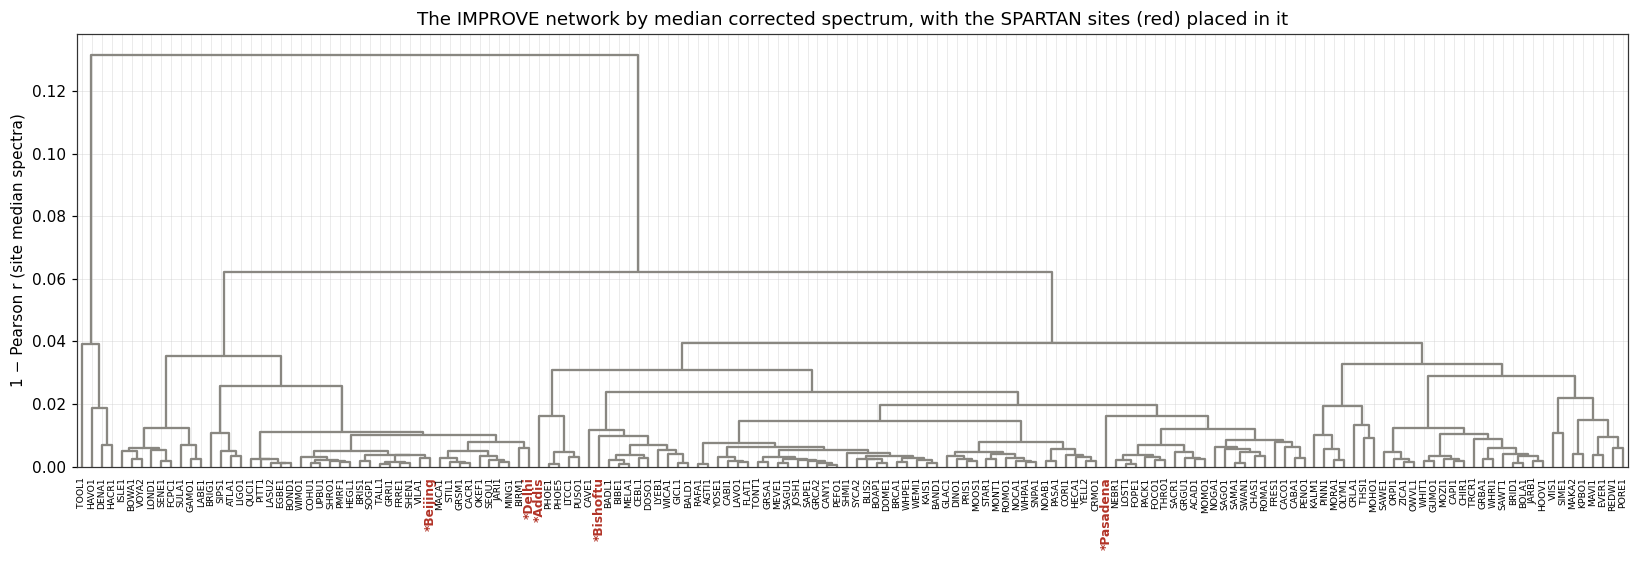

In [9]:
D = squareform(np.clip(1 - R, 0, None), checks=False)
Zs = linkage(D, method='average')
fig, ax = plt.subplots(figsize=(15, 5.2))
dn = dendrogram(Zs, labels=names, leaf_font_size=6, color_threshold=0, ax=ax,
                above_threshold_color='#898781')
for lbl in ax.get_xmajorticklabels():
    if lbl.get_text().startswith('*'):
        lbl.set_color('#B23327'); lbl.set_fontweight('bold'); lbl.set_fontsize(8)
ax.set(ylabel='1 − Pearson r (site median spectra)',
       title='The IMPROVE network by median corrected spectrum, with the SPARTAN sites (red) placed in it')
fig.tight_layout(); fig.savefig(PLOTS / 'site_dendrogram.png', dpi=150); plt.show()

## 5. A validated similarity threshold (Open Specy's discipline)

Every library spectrum's leave-one-out nearest neighbour: its r, and whether the
neighbour shares the spectrum's Ward class. Precision of "same class" as a function of
the r cutoff gives the operating point; the 90%-precision r is the threshold. Then: what
fraction of each SPARTAN target's filters has a library match above it?

leave-one-out nearest neighbour: median r 0.9989
  same Ward class  base rate 99.0% -> at the strictest cutoff 100.0%
  EC within 25%    base rate 30.8% -> at the strictest cutoff 64.2%
  same site        base rate 12.2% -> at the strictest cutoff 68.1%

NO USABLE THRESHOLD on "EC within 25%". Precision never reaches 75% at any similarity cutoff: the best is 64% at r >= 0.9999, and that cutoff keeps only 0.5% of the library. Base rate is 31%, so extreme spectral similarity roughly doubles the odds of EC agreement and no more.
This is the central negative result of the notebook: a near-identical spectrum is NOT a guarantee of a near-identical EC loading, so "nearest analogs" cannot be treated as calibration-equivalent samples however tight the match.
same-site precision rises 12% -> 68%: spectral twins are mostly NOT from the same site, which is the encouraging half -- the library does generalize across sites.


,target,median_best_r,pct_above_threshold,pct_below_0.99
0,Addis (ETAD),0.9939,0.0,18.4
1,Bishoftu (ETBI),0.9988,0.0,0.0
2,Delhi (INDH),0.9964,0.0,7.9
3,Beijing (CHTS),0.9986,0.0,3.1
4,Pasadena (USPA),0.9966,0.0,17.7


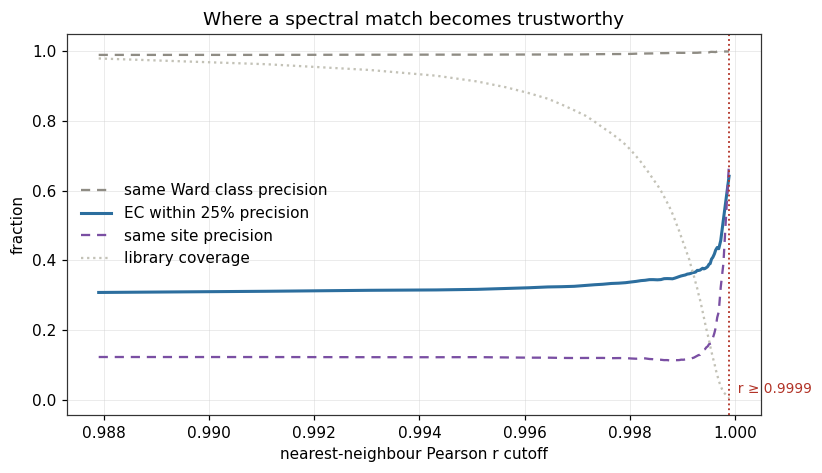

In [10]:
# Same-class agreement is the wrong yardstick here: with k=4 and one class holding 59%
# of the library, a random neighbour is already ~99% "correct", so precision is flat and
# any threshold read off it is meaningless. Two harder criteria that match what a match
# is FOR: does the neighbour carry the same EC loading (within 25%), and is it even from
# the same site?
Ls_std = ss.standardize(LIB)
lib_lab = lib.cluster.to_numpy()
lib_ec = lib.TOR_EC_loading_ug.to_numpy(float)
lib_site_arr = lib.Site.to_numpy()
nn_r = np.empty(len(LIB)); nn_same = np.empty(len(LIB), bool)
nn_ec_ok = np.zeros(len(LIB), bool); nn_site = np.empty(len(LIB), bool)
for start in range(0, len(LIB), 1024):
    block = slice(start, start + 1024)
    Rb = Ls_std[block] @ Ls_std.T
    rows_i = np.arange(Rb.shape[0])
    Rb[rows_i, np.arange(start, start + Rb.shape[0])] = -np.inf
    j = Rb.argmax(axis=1)
    nn_r[block] = Rb[rows_i, j]
    nn_same[block] = lib_lab[j] == lib_lab[block]
    nn_site[block] = lib_site_arr[j] == lib_site_arr[block]
    a, b = lib_ec[block], lib_ec[j]
    with np.errstate(invalid='ignore', divide='ignore'):
        nn_ec_ok[block] = np.abs(a - b) / np.maximum(a, 1e-9) <= 0.25

valid_ec = np.isfinite(lib_ec) & np.isfinite(lib_ec[np.arange(len(LIB))])
grid = np.quantile(nn_r, np.linspace(0.02, 0.995, 60))
curves = {
    'same Ward class': np.array([nn_same[nn_r >= t].mean() for t in grid]),
    'EC within 25%': np.array([nn_ec_ok[(nn_r >= t) & valid_ec].mean() for t in grid]),
    'same site': np.array([nn_site[nn_r >= t].mean() for t in grid]),
}
cover = np.array([(nn_r >= t).mean() for t in grid])
print(f'leave-one-out nearest neighbour: median r {np.median(nn_r):.4f}')
for name, c in curves.items():
    print(f'  {name:<16} base rate {c[0]:.1%} -> at the strictest cutoff {c[-1]:.1%}')

TASK = 'EC within 25%'
prec = curves[TASK]
TARGET_PREC = 0.75
reached = bool((prec >= TARGET_PREC).any())
thr_idx = int(np.argmax(prec >= TARGET_PREC)) if reached else int(np.argmax(prec))
R_THR = float(grid[thr_idx])
if reached:
    print(f'\noperating point on "{TASK}": r >= {R_THR:.4f} reaches {prec[thr_idx]:.0%} '
          f'precision, covering {cover[thr_idx]:.0%} of the library (base rate {prec[0]:.0%}).')
else:
    print(f'\nNO USABLE THRESHOLD on "{TASK}". Precision never reaches {TARGET_PREC:.0%} at '
          f'any similarity cutoff: the best is {prec[thr_idx]:.0%} at r >= {R_THR:.4f}, and '
          f'that cutoff keeps only {cover[thr_idx]:.1%} of the library. Base rate is '
          f'{prec[0]:.0%}, so extreme spectral similarity roughly doubles the odds of EC '
          'agreement and no more.')
    print('This is the central negative result of the notebook: a near-identical spectrum '
          'is NOT a guarantee of a near-identical EC loading, so "nearest analogs" cannot '
          'be treated as calibration-equivalent samples however tight the match.')
print(f'same-site precision rises {curves["same site"][0]:.0%} -> '
      f'{curves["same site"][-1]:.0%}: spectral twins are mostly NOT from the same site, '
      'which is the encouraging half -- the library does generalize across sites.')

rows = []
for k, lab in TARGETS.items():
    best = ss.correlation_matrix(X[k], LIB).max(axis=1)
    rows.append({'target': lab, 'median_best_r': round(float(np.median(best)), 4),
                 'pct_above_threshold': round(100 * float((best >= R_THR).mean()), 1),
                 'pct_below_0.99': round(100 * float((best < 0.99).mean()), 1)})
thr = pd.DataFrame(rows); thr.to_csv(OUT / 'threshold_coverage.csv', index=False)
display(thr)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
for (name, c), colour in zip(curves.items(), ['#8F8C84', '#2C6E9E', '#7A4FA3']):
    ax.plot(grid, c, color=colour, lw=2 if name == TASK else 1.5,
            ls='-' if name == TASK else (0, (4, 3)), label=f'{name} precision')
ax.plot(grid, cover, color='#c3c2b7', lw=1.5, ls=':', label='library coverage')
ax.axvline(R_THR, color='#B23327', lw=1.2, ls=':')
ax.text(R_THR, 0.02, f'  r ≥ {R_THR:.4f}', color='#B23327', fontsize=9)
ax.set(xlabel='nearest-neighbour Pearson r cutoff', ylabel='fraction',
       title='Where a spectral match becomes trustworthy')
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(PLOTS / 'threshold_curve.png', dpi=150); plt.show()

## 6. The IMPROVE network compared with itself

Sections 4-5 asked "which IMPROVE sites are near the SPARTAN targets". This asks the
network question directly: **which IMPROVE sites resemble each other**, which are
isolated, and whether the structure is regional. Same per-site median corrected spectra,
now read as a 162x162 matrix with the SPARTAN columns removed.

In [11]:
improve_names = [n for n in names if not n.startswith('*')]
ii = [names.index(n) for n in improve_names]
R_imp = R[np.ix_(ii, ii)]
np.fill_diagonal(R_imp, np.nan)
imp_df = pd.DataFrame(R_imp, index=improve_names, columns=improve_names)
imp_df.to_csv(OUT / 'improve_site_correlation.csv')

pairs = [(improve_names[a], improve_names[b], float(R_imp[a, b]))
         for a in range(len(improve_names)) for b in range(a + 1, len(improve_names))]
pairs.sort(key=lambda t: -t[2])
top_pairs = pd.DataFrame(pairs[:15], columns=['site_A', 'site_B', 'r']).round(5)
print('Most similar IMPROVE site pairs (median corrected spectra):')
display(top_pairs)
print('Least similar pairs:')
display(pd.DataFrame(pairs[-10:], columns=['site_A', 'site_B', 'r']).round(4))

isolation = pd.DataFrame({
    'site': improve_names,
    'best_r_to_any_site': np.nanmax(R_imp, axis=1).round(5),
    'median_r_to_network': np.nanmedian(R_imp, axis=1).round(5),
    'nearest_site': [improve_names[int(np.nanargmax(R_imp[a]))] for a in range(len(improve_names))],
    'n_spectra': [int(counts[n]) for n in improve_names],
}).sort_values('best_r_to_any_site')
isolation.to_csv(OUT / 'improve_site_isolation.csv', index=False)
print('Most ISOLATED IMPROVE sites (no close spectral partner anywhere in the network):')
display(isolation.head(12))
print('Most TYPICAL sites (highest median similarity to the whole network):')
display(isolation.sort_values('median_r_to_network', ascending=False).head(8))

Most similar IMPROVE site pairs (median corrected spectra):


,site_A,site_B,r
0,CANY1,PEFO1,0.99944
1,LOST1,FOPE1,0.99925
2,BIBE1,MELA1,0.99924
3,RAFA1,AGTI1,0.99912
4,TALL1,GRRI1,0.99904
5,PHOE1,PHOE5,0.99904
6,BOAP1,DOME1,0.99899
7,TALL1,FRRE1,0.99899
8,GRSM1,CACR1,0.99898
9,EGBE1,BOND1,0.99897


Least similar pairs:


,site_A,site_B,r
0,HACR1,SIPS1,0.6618
1,DENA1,SIPS1,0.6614
2,PITT1,TOOL1,0.6582
3,LASU2,TOOL1,0.6528
4,EGBE1,TOOL1,0.6492
5,MACA1,TOOL1,0.6417
6,BOND1,TOOL1,0.6362
7,ATLA1,TOOL1,0.6257
8,LIGO1,TOOL1,0.6176
9,TOOL1,SIPS1,0.5688


Most ISOLATED IMPROVE sites (no close spectral partner anywhere in the network):


,site,best_r_to_any_site,median_r_to_network,nearest_site,n_spectra
139,TOOL1,0.98327,0.82738,DENA1,53
32,HAVO1,0.98922,0.92924,WHRI1,117
57,SIME1,0.98930,0.89098,VIIS1,110
53,VIIS1,0.99055,0.92433,PORE1,111
21,KALM1,0.99214,0.94782,PINN1,121
23,THSI1,0.99217,0.95720,OLYM1,120
46,MOHO1,0.99276,0.95061,SAWT1,113
10,TRCR1,0.99292,0.94615,BRID1,124
72,HACR1,0.99297,0.89568,DENA1,102
50,DENA1,0.99297,0.88881,HACR1,112


Most TYPICAL sites (highest median similarity to the whole network):


,site,best_r_to_any_site,median_r_to_network,nearest_site,n_spectra
86,KAIS1,0.99892,0.98262,BAND1,72
80,BLIS2,0.99834,0.98249,KAIS1,97
62,MOMO1,0.99767,0.98219,ACAD1,108
44,ACAD1,0.99767,0.98196,MOMO1,114
106,SYCA2,0.99763,0.98174,BOAP1,60
81,GLAC1,0.99815,0.98165,PRIS1,96
93,WEMI1,0.99788,0.98163,BAND1,65
95,BAND1,0.99892,0.98153,KAIS1,64


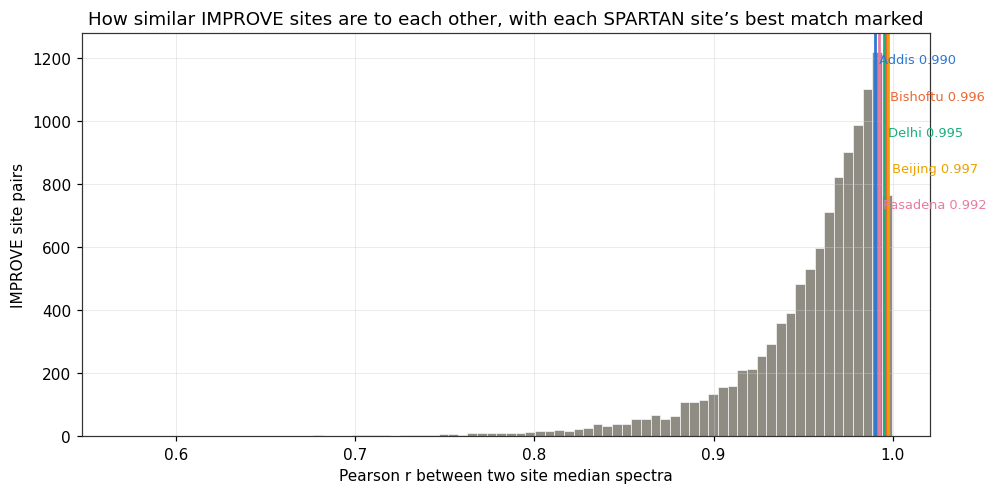

Addis (ETAD)       best IMPROVE match r=0.9902 sits at the 86th percentile of IMPROVE-IMPROVE pair similarity
Bishoftu (ETBI)    best IMPROVE match r=0.9962 sits at the 97th percentile of IMPROVE-IMPROVE pair similarity
Delhi (INDH)       best IMPROVE match r=0.9952 sits at the 95th percentile of IMPROVE-IMPROVE pair similarity
Beijing (CHTS)     best IMPROVE match r=0.9974 sits at the 99th percentile of IMPROVE-IMPROVE pair similarity
Pasadena (USPA)    best IMPROVE match r=0.9921 sits at the 90th percentile of IMPROVE-IMPROVE pair similarity


In [12]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.hist([p[2] for p in pairs], bins=80, color='#8F8C84', edgecolor='white', linewidth=0.4)
for k, lab in TARGETS.items():
    i = names.index(f'*{lab.split(" ")[0]}')
    best = max(R[i, j] for j in ii)
    ax.axvline(best, color=SITE_COLOUR[k], lw=1.8)
    ax.text(best, ax.get_ylim()[1] * (0.95 - 0.09 * list(TARGETS).index(k)),
            f' {lab.split(" ")[0]} {best:.3f}', color=SITE_COLOUR[k], fontsize=8.5, va='top')
ax.set(xlabel='Pearson r between two site median spectra',
       ylabel='IMPROVE site pairs',
       title='How similar IMPROVE sites are to each other, with each SPARTAN site\u2019s best match marked')
fig.tight_layout(); fig.savefig(PLOTS / 'improve_pair_distribution.png', dpi=150); plt.show()

pair_r = np.array([p[2] for p in pairs])
for k, lab in TARGETS.items():
    i = names.index(f'*{lab.split(" ")[0]}')
    best = max(R[i, j] for j in ii)
    print(f'{lab:<18} best IMPROVE match r={best:.4f} sits at the '
          f'{100 * (pair_r < best).mean():.0f}th percentile of IMPROVE-IMPROVE pair similarity')

## 7. Does baselining change who is similar to whom?

Everything so far is AIRSpec-corrected. Raw spectra are baseline-dominated (that is the
phase-3 background-leakage story), so the honest check is whether the network's
similarity structure is the *same* before and after baselining. Raw pool spectra are
restricted to the corrected window (1425-3998 cm-1) so the two spaces are comparable,
and the whole section is recomputed on raw medians.

In [13]:
from phase3_common import load_pool_spectra                              # noqa: E402
full_wcols = list(etad_eval.attrs['wcols'])
raw_pool = load_pool_spectra(lib.AnalysisId.to_numpy(), full_wcols)
raw_pool = raw_pool.set_index('AnalysisId').reindex(lib.AnalysisId.to_numpy())
RAW_FULL = raw_pool[full_wcols].to_numpy(float)
WN_FULL = np.array([float(c) for c in full_wcols])
# the comparison window matches the corrected grid so the two spaces are comparable
win = (WN_FULL >= 1425) & (WN_FULL <= 3999)
raw_wcols = [c for c, m in zip(full_wcols, win) if m]
RAW = RAW_FULL[:, win]
raw_ok = np.isfinite(RAW).all(axis=1)
print(f'raw spectra fetched for {raw_ok.sum():,}/{len(lib):,} pool rows; '
      f'full range {WN_FULL.min():.0f}-{WN_FULL.max():.0f} cm-1 ({len(full_wcols)} channels), '
      f'comparison window {len(raw_wcols)} channels')

raw_site_median = {}
for site in improve_names:
    m = (lib.Site == site).to_numpy() & raw_ok
    if m.sum() >= 20:
        raw_site_median[site] = np.median(RAW[m], axis=0)
shared = [s for s in improve_names if s in raw_site_median]
R_raw = ss.correlation_matrix(np.vstack([raw_site_median[s] for s in shared]),
                              np.vstack([raw_site_median[s] for s in shared]))
np.fill_diagonal(R_raw, np.nan)
sub_idx = [improve_names.index(s) for s in shared]
R_cor = R_imp[np.ix_(sub_idx, sub_idx)]

iu = np.triu_indices(len(shared), 1)
rho = float(pd.Series(R_raw[iu]).corr(pd.Series(R_cor[iu]), method='spearman'))
print(f'\n{len(shared)} sites in both spaces. Spearman between the raw and baselined '
      f'site-similarity matrices: rho = {rho:.3f}')
print(f'raw pair similarity: median {np.nanmedian(R_raw[iu]):.4f}, '
      f'baselined: {np.nanmedian(R_cor[iu]):.4f} '
      '(baselining SEPARATES sites: removing the shared PTFE/background makes the '
      'remaining differences a larger share of what is left)')

moved = []
for a, site in enumerate(shared):
    nn_raw = shared[int(np.nanargmax(R_raw[a]))]
    nn_cor = shared[int(np.nanargmax(R_cor[a]))]
    moved.append({'site': site, 'nearest_raw': nn_raw, 'nearest_baselined': nn_cor,
                  'changed': nn_raw != nn_cor,
                  'rank_of_raw_nn_after': int((R_cor[a] > R_cor[a, shared.index(nn_raw)]).sum()) + 1})
moved = pd.DataFrame(moved)
moved.to_csv(OUT / 'nearest_neighbour_raw_vs_baselined.csv', index=False)
print(f"\nnearest-neighbour site changes after baselining: "
      f"{moved.changed.sum()}/{len(moved)} sites ({moved.changed.mean():.0%})")
display(moved[moved.changed].head(12))

raw spectra fetched for 13,634/13,634 pool rows; full range 500-3998 cm-1 (2722 channels), comparison window 2002 channels



151 sites in both spaces. Spearman between the raw and baselined site-similarity matrices: rho = 0.587
raw pair similarity: median 0.9990, baselined: 0.9681 (baselining SEPARATES sites: removing the shared PTFE/background makes the remaining differences a larger share of what is left)

nearest-neighbour site changes after baselining: 139/151 sites (92%)


,site,nearest_raw,nearest_baselined,changed,rank_of_raw_nn_after
0,YOSE1,ACAD1,CABI1,True,46
1,SAMA1,JARI1,SWAN1,True,24
2,PMRF1,SENE1,HEGL1,True,34
3,BRID1,MOZI1,BOLA1,True,6
4,CEBL1,MELA1,DOSO1,True,2
5,GRSM1,JARI1,CACR1,True,3
7,CAPI1,GRBA1,CHIR1,True,24
8,TALL1,WIMO1,GRRI1,True,10
9,CHAS1,SAGO1,ROMA1,True,8
10,TRCR1,MAKA2,BRID1,True,14


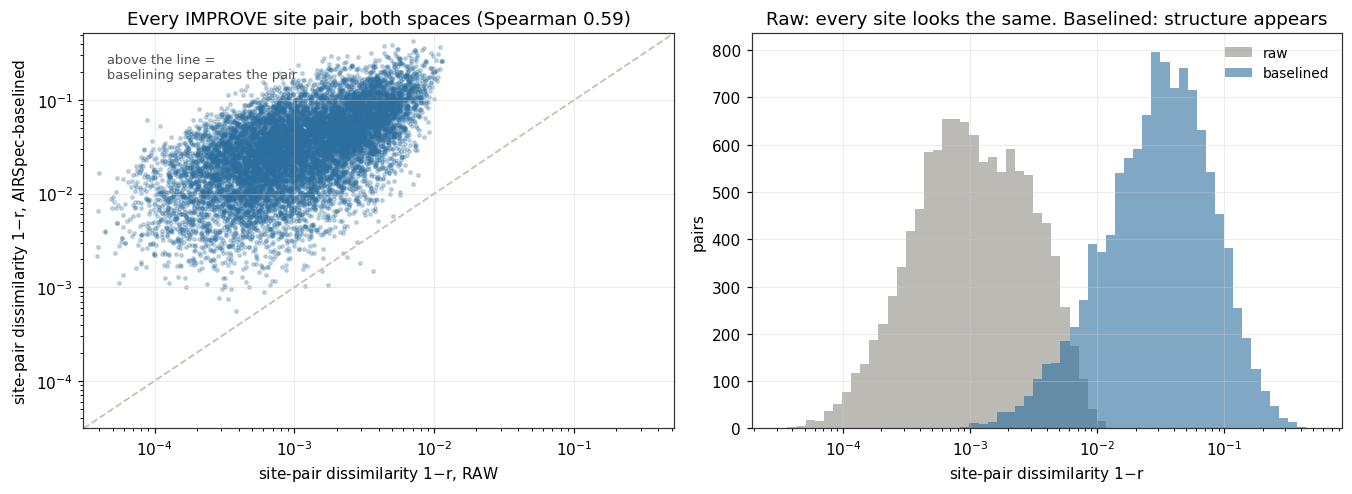

In [14]:
# Plot DISSIMILARITY 1-r on log axes: in raw space every pair sits at r ~ 0.999, so a
# linear r axis collapses the whole raw network onto one tick and hides the result.
d_raw, d_cor = 1 - R_raw[iu], 1 - R_cor[iu]
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
axes[0].scatter(d_raw, d_cor, s=5, color='#2C6E9E', alpha=0.25, rasterized=True)
lims = [min(d_raw.min(), d_cor.min()) * 0.8, max(d_raw.max(), d_cor.max()) * 1.2]
axes[0].plot(lims, lims, ls='--', lw=1.2, color='#c3c2b7')
axes[0].set(xscale='log', yscale='log', xlim=lims, ylim=lims,
            xlabel='site-pair dissimilarity 1$-$r, RAW',
            ylabel='site-pair dissimilarity 1$-$r, AIRSpec-baselined',
            title=f'Every IMPROVE site pair, both spaces (Spearman {rho:.2f})')
axes[0].text(0.04, 0.95, 'above the line =\nbaselining separates the pair',
             transform=axes[0].transAxes, va='top', fontsize=8.5, color='#52514e')
bins = np.logspace(np.log10(lims[0]), np.log10(lims[1]), 60)
axes[1].hist(d_raw, bins=bins, alpha=0.6, color='#8F8C84', label='raw', edgecolor='none')
axes[1].hist(d_cor, bins=bins, alpha=0.6, color='#2C6E9E', label='baselined', edgecolor='none')
axes[1].set(xscale='log', xlabel='site-pair dissimilarity 1$-$r', ylabel='pairs',
            title='Raw: every site looks the same. Baselined: structure appears')
axes[1].legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(PLOTS / 'raw_vs_baselined_sites.png', dpi=150); plt.show()

In [15]:
# Do the SPARTAN targets' nearest IMPROVE sites survive baselining?
rows = []
for k, lab in TARGETS.items():
    tgt_raw = None
    if k == 'addis':
        raw_t = etad_eval[raw_wcols].to_numpy(float)
        tgt_raw = np.median(raw_t, axis=0)
    if tgt_raw is None:
        rows.append({'target': lab, 'nearest_raw': 'n/a (no raw target export)',
                     'nearest_baselined': site_near.set_index('target')
                     .loc[lab, 'nearest_IMPROVE_sites'].split(',')[0]})
        continue
    rr = ss.correlation_matrix(tgt_raw[None, :],
                               np.vstack([raw_site_median[s] for s in shared])).ravel()
    rows.append({'target': lab, 'nearest_raw': f'{shared[int(np.argmax(rr))]} ({rr.max():.4f})',
                 'nearest_baselined': site_near.set_index('target')
                 .loc[lab, 'nearest_IMPROVE_sites'].split(',')[0]})
display(pd.DataFrame(rows))
print('Only Addis has a raw target export in this notebook; the other four targets are '
      'distributed as corrected spectra only, so their raw comparison needs the SPARTAN '
      'raw pulls and is left for a follow-up.')

,target,nearest_raw,nearest_baselined
0,Addis (ETAD),PUSO1 (0.9996),NOGA1 (0.9902)
1,Bishoftu (ETBI),n/a (no raw target export),BIBE1 (0.9962)
2,Delhi (INDH),n/a (no raw target export),PITT1 (0.9952)
3,Beijing (CHTS),n/a (no raw target export),VILA1 (0.9974)
4,Pasadena (USPA),n/a (no raw target export),PACK1 (0.9921)


Only Addis has a raw target export in this notebook; the other four targets are distributed as corrected spectra only, so their raw comparison needs the SPARTAN raw pulls and is left for a follow-up.


## 8. Addis in raw space: which IMPROVE spectra does it actually match?

The site-level result says raw-space similarity is background similarity. This is the
per-filter version, and the one to look at directly: take every Addis filter, find its
nearest IMPROVE **spectra** in raw space and in baselined space, and ask whether they are
the same spectra. Then plot them — including the 1150-1300 cm-1 PTFE doublet that the
corrected grid cuts away, because that is what raw matching is mostly looking at.

In [16]:
A_raw = etad_eval[raw_wcols].to_numpy(float)          # matched window
A_raw_full = etad_eval[full_wcols].to_numpy(float)
A_cor = X['addis']
ok = raw_ok

K_AN = 50
idx_raw, sc_raw = ss.nearest_analogs(A_raw, RAW[ok], k=K_AN)
idx_cor, sc_cor = ss.nearest_analogs(A_cor, LIB, k=K_AN)
pool_ids_raw = lib.AnalysisId.to_numpy()[ok]
pool_site_raw = lib.Site.to_numpy()[ok]
pool_ids_cor = lib.AnalysisId.to_numpy()
pool_site_cor = lib.Site.to_numpy()

overlap = [len(set(pool_ids_raw[a]) & set(pool_ids_cor[b])) / K_AN
           for a, b in zip(idx_raw, idx_cor)]
print(f'Per-Addis-filter overlap between its top-{K_AN} RAW analogs and its top-{K_AN} '
      f'BASELINED analogs: median {100 * np.median(overlap):.0f}%, '
      f'mean {100 * np.mean(overlap):.0f}%, '
      f'{100 * np.mean(np.array(overlap) == 0):.0f}% of filters share NONE')
print(f'raw-space match quality:       median top-1 r {np.median(sc_raw[:, 0]):.4f}')
print(f'baselined-space match quality: median top-1 r {np.median(sc_cor[:, 0]):.4f}')

top_raw = pd.Series(pool_site_raw[idx_raw.ravel()]).value_counts().head(8)
top_cor = pd.Series(pool_site_cor[idx_cor.ravel()]).value_counts().head(8)
sites_cmp = pd.DataFrame({'raw analog sites': top_raw, 'baselined analog sites': top_cor})
display(sites_cmp.fillna(0).astype(int))
pd.DataFrame({'AnalysisId_raw_top1': pool_ids_raw[idx_raw[:, 0]],
              'site_raw_top1': pool_site_raw[idx_raw[:, 0]],
              'r_raw_top1': sc_raw[:, 0].round(5),
              'AnalysisId_cor_top1': pool_ids_cor[idx_cor[:, 0]],
              'site_cor_top1': pool_site_cor[idx_cor[:, 0]],
              'r_cor_top1': sc_cor[:, 0].round(5),
              'top50_overlap': np.round(overlap, 3)}).to_csv(
    OUT / 'addis_raw_vs_baselined_analogs.csv', index=False)

Per-Addis-filter overlap between its top-50 RAW analogs and its top-50 BASELINED analogs: median 12%, mean 12%, 5% of filters share NONE
raw-space match quality:       median top-1 r 0.9999
baselined-space match quality: median top-1 r 0.9939


,raw analog sites,baselined analog sites
ATLA1,246,0
BIRM1,296,627
CHAS1,0,310
FRES1,0,388
LTCC1,493,524
PHOE1,413,936
PHOE5,330,948
PINN1,254,0
PITT1,0,370
PUSO1,846,872


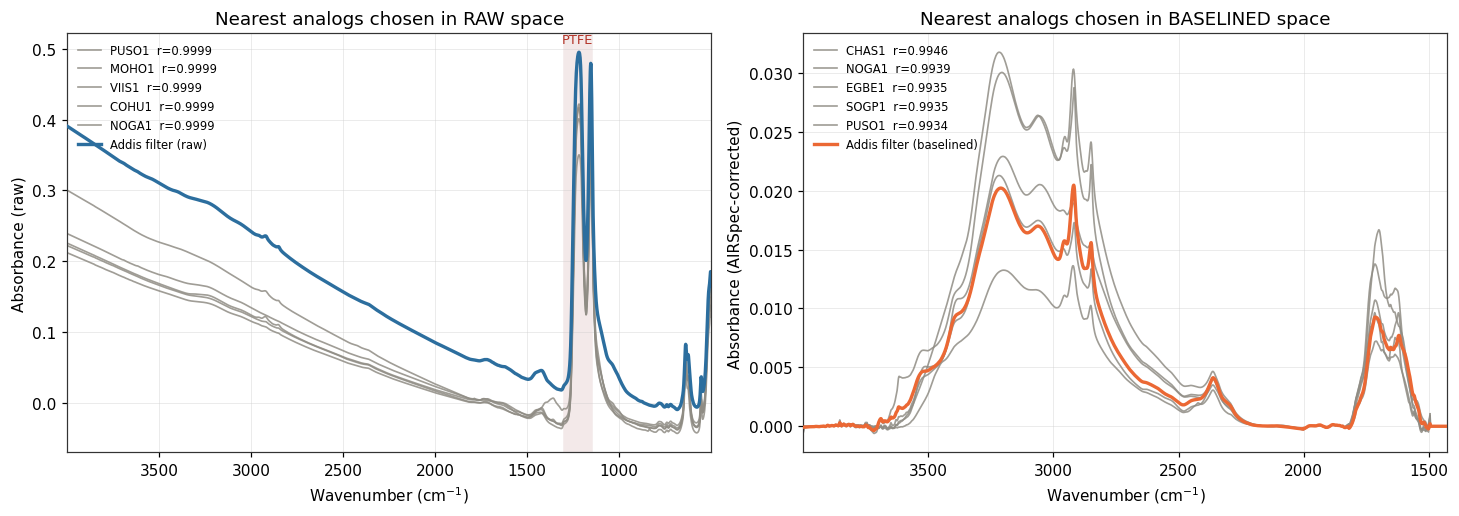

In [17]:
# The representative Addis filter: its raw analogs (drawn raw) and its baselined analogs
# (drawn baselined), full raw range on the left so the PTFE doublet is visible.
i = int(np.argmax(ss.correlation_matrix(A_cor, np.median(A_cor, axis=0)[None, :]).ravel()))
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))

pool_full = RAW_FULL[ok]
for j, li in enumerate(idx_raw[i][:5]):
    axes[0].plot(WN_FULL, pool_full[li], lw=1.1, color='#8F8C84', alpha=0.85,
                 label=f'{pool_site_raw[li]}  r={sc_raw[i, j]:.4f}')
axes[0].plot(WN_FULL, A_raw_full[i], lw=2.2, color='#2C6E9E', zorder=5,
             label='Addis filter (raw)')
axes[0].axvspan(1150, 1300, color='#f3e9e9', zorder=0)
axes[0].text(1225, axes[0].get_ylim()[1], 'PTFE', ha='center', va='top',
             fontsize=8.5, color='#B23327')
axes[0].set(xlim=(WN_FULL.max(), WN_FULL.min()), xlabel='Wavenumber (cm$^{-1}$)',
            ylabel='Absorbance (raw)', title='Nearest analogs chosen in RAW space')
axes[0].legend(frameon=False, fontsize=7.6, loc='upper left')

for j, li in enumerate(idx_cor[i][:5]):
    axes[1].plot(WN, LIB[li], lw=1.1, color='#8F8C84', alpha=0.85,
                 label=f'{pool_site_cor[li]}  r={sc_cor[i, j]:.4f}')
axes[1].plot(WN, A_cor[i], lw=2.2, color='#eb6834', zorder=5,
             label='Addis filter (baselined)')
axes[1].set(xlim=(WN.max(), WN.min()), xlabel='Wavenumber (cm$^{-1}$)',
            ylabel='Absorbance (AIRSpec-corrected)',
            title='Nearest analogs chosen in BASELINED space')
axes[1].legend(frameon=False, fontsize=7.6, loc='upper left')
fig.tight_layout(); fig.savefig(PLOTS / 'addis_raw_vs_baselined_analogs.png', dpi=150)
plt.show()

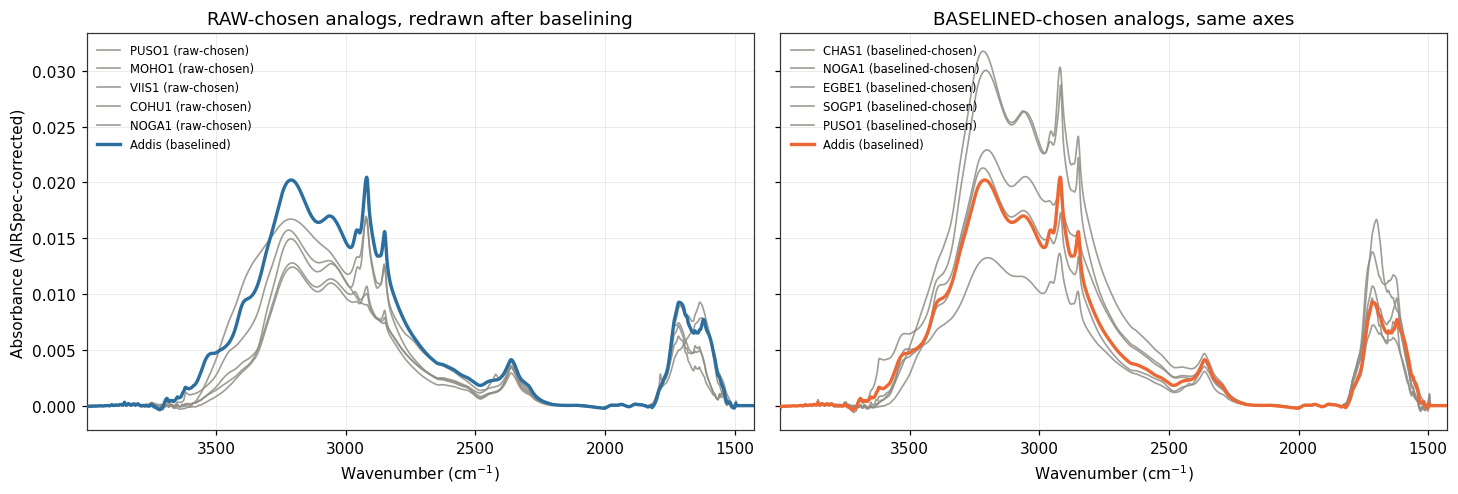

The top-50 RAW-chosen analogs of this filter, scored in baselined space: median r 0.9731 (its true baselined top-50 median is 0.9901) -- a raw match is not a baselined match.


In [18]:
# The same raw-chosen analogs, redrawn AFTER baselining: does a raw match survive?
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.6), sharey=True)
cor_row = {int(a): r for r, a in enumerate(lib.AnalysisId.to_numpy())}
for j, li in enumerate(idx_raw[i][:5]):
    row = cor_row[int(pool_ids_raw[li])]
    axes[0].plot(WN, LIB[row], lw=1.1, color='#8F8C84', alpha=0.85,
                 label=f'{pool_site_raw[li]} (raw-chosen)')
axes[0].plot(WN, A_cor[i], lw=2.2, color='#2C6E9E', zorder=5, label='Addis (baselined)')
axes[0].set(xlim=(WN.max(), WN.min()), xlabel='Wavenumber (cm$^{-1}$)',
            ylabel='Absorbance (AIRSpec-corrected)',
            title='RAW-chosen analogs, redrawn after baselining')
axes[0].legend(frameon=False, fontsize=7.6, loc='upper left')
for j, li in enumerate(idx_cor[i][:5]):
    axes[1].plot(WN, LIB[li], lw=1.1, color='#8F8C84', alpha=0.85,
                 label=f'{pool_site_cor[li]} (baselined-chosen)')
axes[1].plot(WN, A_cor[i], lw=2.2, color='#eb6834', zorder=5, label='Addis (baselined)')
axes[1].set(xlim=(WN.max(), WN.min()), xlabel='Wavenumber (cm$^{-1}$)',
            title='BASELINED-chosen analogs, same axes')
axes[1].legend(frameon=False, fontsize=7.6, loc='upper left')
fig.tight_layout(); fig.savefig(PLOTS / 'addis_raw_analogs_after_baselining.png', dpi=150)
plt.show()

raw_chosen_rows = [cor_row[int(pool_ids_raw[li])] for li in idx_raw[i][:K_AN]]
r_after = ss.correlation_matrix(A_cor[i][None, :], LIB[raw_chosen_rows]).ravel()
print(f'The top-{K_AN} RAW-chosen analogs of this filter, scored in baselined space: '
      f'median r {np.median(r_after):.4f} (its true baselined top-{K_AN} median is '
      f'{np.median(sc_cor[i]):.4f}) -- a raw match is not a baselined match.')

## 9. Do the Ethiopian seasons have different analogs?

Addis spans three seasons — Dry (Oct–Feb, n=105), Belg (Mar–May, n=61) and Kiremt
(Jun–Sep, n=73) — and the phase-3 thread treats them as chemically different (the
char-similarity anomaly is almost entirely dry-season). This section takes the **median
baselined spectrum of each season** and asks the network the same question separately:
which IMPROVE spectra are its analogs, from which sites, and from which time of year?
If the seasons draw different analogs, one pooled Addis cohort is the wrong object.

In [19]:
SEASONS = ['Dry (Oct-Feb)', 'Belg (Mar-May)', 'Kiremt (Jun-Sep)']
S_COLOUR = {'Dry (Oct-Feb)': '#B23327', 'Belg (Mar-May)': '#eda100',
            'Kiremt (Jun-Sep)': '#2C6E9E'}
season_lab = etad_eval['season'].fillna('unknown').to_numpy()
season_median = {}
for name in SEASONS:
    m = season_lab == name
    season_median[name] = np.median(X['addis'][m], axis=0)
    print(f'{name:<18} n={m.sum():>3}')

M_seas = np.vstack([season_median[n] for n in SEASONS])
print('\nSeason medians against each other (Pearson r):')
display(pd.DataFrame(ss.correlation_matrix(M_seas, M_seas).round(4),
                     index=SEASONS, columns=SEASONS))

K_S = 200
rows, an_idx = [], {}
lib_month = lib.month.to_numpy()
for name in SEASONS:
    idx, sc = ss.nearest_analogs(season_median[name][None, :], LIB, k=K_S)
    an_idx[name] = idx[0]
    g = lib.iloc[idx[0]]
    rows.append({
        'Addis season': name,
        'top1_r': round(float(sc[0, 0]), 5),
        f'median_r_top{K_S}': round(float(np.median(sc[0])), 5),
        'top sites': ', '.join(f'{s}' for s in g.Site.value_counts().head(4).index),
        'analog median OC/EC': round(float(g.OC_EC_ratio.median()), 2),
        'analog median EC (ug)': round(float(g.TOR_EC_loading_ug.median()), 2),
        'pct analogs Jul-Oct': round(100 * float(np.isin(lib_month[idx[0]], [7, 8, 9, 10]).mean()), 0),
        'pct analogs in smoke class': round(100 * float((g.cluster == smoke_class).mean()), 0),
        'pct analogs in smoke lineage': round(100 * float(g.smoke_lineage.mean()), 1),
    })
season_analogs = pd.DataFrame(rows)
season_analogs.to_csv(OUT / 'season_analogs.csv', index=False)
display(season_analogs)

print(f'Overlap between the top-{K_S} analog sets:')
for a in range(len(SEASONS)):
    for b in range(a + 1, len(SEASONS)):
        ov = len(set(an_idx[SEASONS[a]]) & set(an_idx[SEASONS[b]])) / K_S
        print(f'  {SEASONS[a]:<18} vs {SEASONS[b]:<18} {100 * ov:>5.0f}%')

Dry (Oct-Feb)      n=105
Belg (Mar-May)     n= 61
Kiremt (Jun-Sep)   n= 73

Season medians against each other (Pearson r):


,Dry (Oct-Feb),Belg (Mar-May),Kiremt (Jun-Sep)
Dry (Oct-Feb),1.0000,0.9496,0.9339
Belg (Mar-May),0.9496,1.0000,0.9800
Kiremt (Jun-Sep),0.9339,0.9800,1.0000


,Addis season,top1_r,median_r_top200,top sites,analog median OC/EC,analog median EC (ug),pct analogs Jul-Oct,pct analogs in smoke class,pct analogs in smoke lineage
0,Dry (Oct-Feb),0.99644,0.99098,"BIBE1, CEBL1, SACR1, TALL1",4.87,4.14,42.0,0.0,0.0
1,Belg (Mar-May),0.99175,0.97624,"LTCC1, PUSO1, PHOE5, PHOE1",3.33,12.02,23.0,0.0,10.5
2,Kiremt (Jun-Sep),0.99504,0.98007,"PUSO1, LTCC1, BIRM1, PHOE5",3.08,18.92,16.0,14.0,15.5


Overlap between the top-200 analog sets:
  Dry (Oct-Feb)      vs Belg (Mar-May)         0%
  Dry (Oct-Feb)      vs Kiremt (Jun-Sep)       0%
  Belg (Mar-May)     vs Kiremt (Jun-Sep)      28%


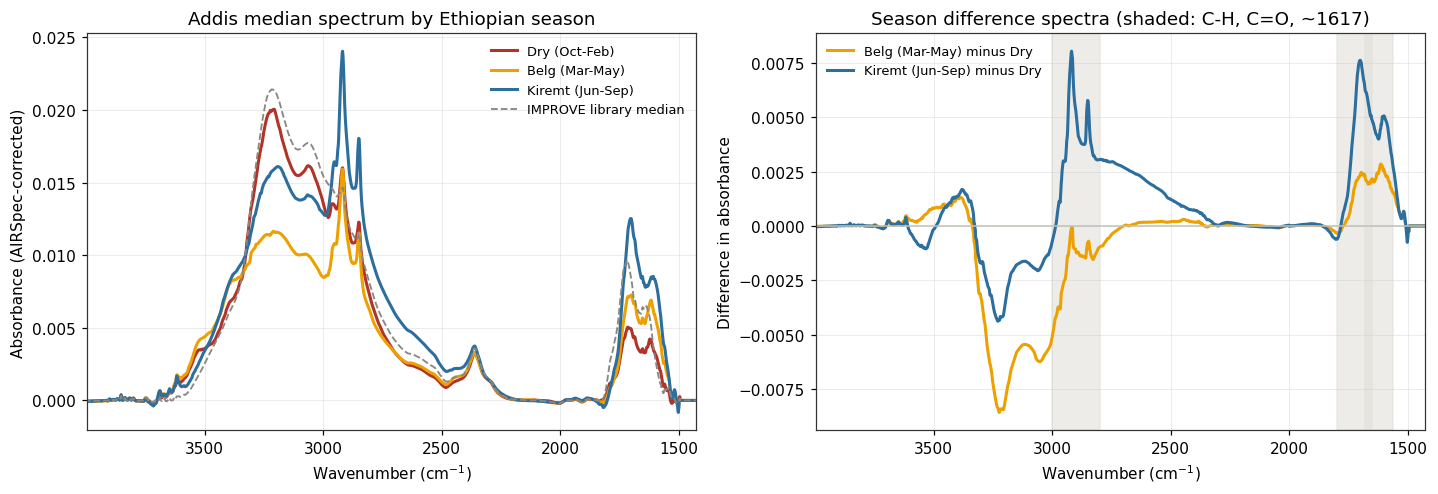

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))
for name in SEASONS:
    axes[0].plot(WN, season_median[name], lw=2, color=S_COLOUR[name], label=f'{name}')
axes[0].plot(WN, np.median(LIB, axis=0), lw=1.2, color='#898781', ls='--',
             label='IMPROVE library median')
axes[0].set(xlim=(WN.max(), WN.min()), xlabel='Wavenumber (cm$^{-1}$)',
            ylabel='Absorbance (AIRSpec-corrected)',
            title='Addis median spectrum by Ethiopian season')
axes[0].legend(frameon=False, fontsize=8.5)

dry = season_median['Dry (Oct-Feb)']
for name in SEASONS:
    if name == 'Dry (Oct-Feb)':
        continue
    axes[1].plot(WN, season_median[name] - dry, lw=2, color=S_COLOUR[name],
                 label=f'{name} minus Dry')
axes[1].axhline(0, color='#c3c2b7', lw=1)
for lo, hi, nm in [(2800, 3000, 'C-H'), (1650, 1800, 'C=O'), (1560, 1680, '~1617')]:
    axes[1].axvspan(lo, hi, color='#e1e0d9', alpha=0.6, zorder=0)
axes[1].set(xlim=(WN.max(), WN.min()), xlabel='Wavenumber (cm$^{-1}$)',
            ylabel='Difference in absorbance',
            title='Season difference spectra (shaded: C-H, C=O, ~1617)')
axes[1].legend(frameon=False, fontsize=8.5)
fig.tight_layout(); fig.savefig(PLOTS / 'season_medians.png', dpi=150); plt.show()

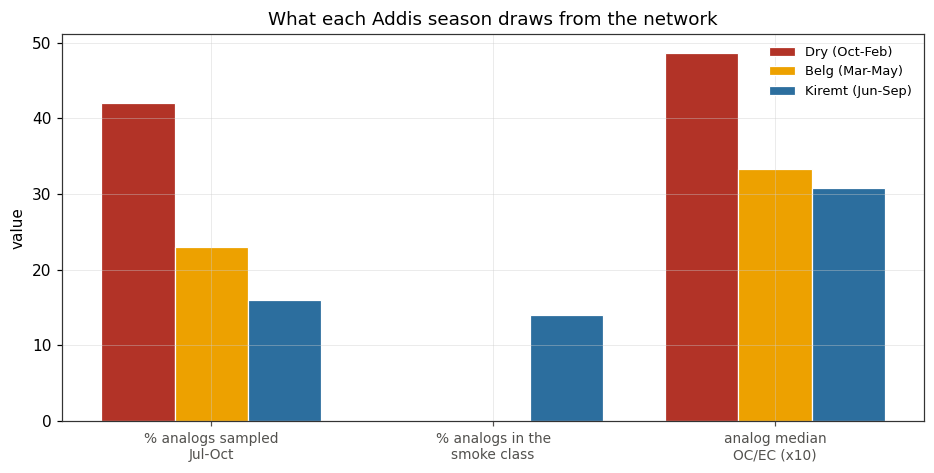

In [21]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))
width = 0.26
metrics = ['pct analogs Jul-Oct', 'pct analogs in smoke class', 'analog median OC/EC']
xpos = np.arange(len(metrics))
for i, name in enumerate(SEASONS):
    row = season_analogs.set_index('Addis season').loc[name]
    vals = [row[m] if m != 'analog median OC/EC' else row[m] * 10 for m in metrics]
    ax.bar(xpos + (i - 1) * width, vals, width, color=S_COLOUR[name], label=name,
           edgecolor='white', linewidth=0.8)
ax.set_xticks(xpos, ['% analogs sampled\nJul-Oct', '% analogs in the\nsmoke class',
                     'analog median\nOC/EC (x10)'], fontsize=9)
ax.tick_params(axis='x', colors='#52514e')
ax.set(ylabel='value', title='What each Addis season draws from the network')
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout(); fig.savefig(PLOTS / 'season_analog_character.png', dpi=150); plt.show()

### Is the seasonal difference composition, or just loading again?

The three seasons' analogs differ 4.6x in median EC loading, and Addis's own seasons
differ in deposit. Same discipline as the smoke class: check whether Addis's per-season
loading tracks its analogs' loading, then repeat the search inside a **fixed loading
band** so every season is matched against the same slice of the library.

In [22]:
etad_eval = etad_eval.assign(peak_abs=X['addis'].max(axis=1))
season_load = etad_eval.groupby('season').agg(
    n=('Fabs', 'size'), median_Fabs=('Fabs', 'median'),
    median_peak_abs=('peak_abs', 'median')).round(4).reindex(SEASONS)
season_load['analog_median_EC_ug'] = season_analogs.set_index('Addis season')['analog median EC (ug)']
display(season_load)
print('If the analog EC ordering follows the Addis Fabs ordering, the seasonal analog '
      'difference is at least partly a loading match, not a composition match.')

band = lib.TOR_EC_loading_ug.between(3, 12) & lib.OC_EC_ratio.notna()
LIB_B = LIB[band.to_numpy()]
lib_b = lib[band].reset_index(drop=True)
print(f'\nloading-matched library slice: {band.sum():,} filters with EC 3-12 ug '
      f'(median {lib_b.TOR_EC_loading_ug.median():.1f})')
rows, an_b = [], {}
for name in SEASONS:
    idx, sc = ss.nearest_analogs(season_median[name][None, :], LIB_B, k=K_S)
    an_b[name] = idx[0]
    g = lib_b.iloc[idx[0]]
    rows.append({'Addis season': name, 'top1_r': round(float(sc[0, 0]), 5),
                 'top sites': ', '.join(g.Site.value_counts().head(4).index),
                 'analog median EC (ug)': round(float(g.TOR_EC_loading_ug.median()), 2),
                 'analog median OC/EC': round(float(g.OC_EC_ratio.median()), 2),
                 'pct Jul-Oct': round(100 * float(np.isin(g.month, [7, 8, 9, 10]).mean()), 0),
                 'pct smoke lineage': round(100 * float(g.smoke_lineage.mean()), 1)})
matched = pd.DataFrame(rows)
matched.to_csv(OUT / 'season_analogs_loading_matched.csv', index=False)
display(matched)
print(f'Overlap between the loading-matched top-{K_S} sets:')
for a in range(len(SEASONS)):
    for b in range(a + 1, len(SEASONS)):
        ov = len(set(an_b[SEASONS[a]]) & set(an_b[SEASONS[b]])) / K_S
        print(f'  {SEASONS[a]:<18} vs {SEASONS[b]:<18} {100 * ov:>5.0f}%')
print('\nIf the sets STILL barely overlap inside one loading band, the seasons really do '
      'draw different analogs; if they now overlap heavily, the headline 0% was loading.')

,n,median_Fabs,median_peak_abs,analog_median_EC_ug
season,,,,
Dry (Oct-Feb),105,43.1756,0.0204,4.14
Belg (Mar-May),61,47.1103,0.0161,12.02
Kiremt (Jun-Sep),73,56.1327,0.0241,18.92


If the analog EC ordering follows the Addis Fabs ordering, the seasonal analog difference is at least partly a loading match, not a composition match.

loading-matched library slice: 6,382 filters with EC 3-12 ug (median 5.6)


,Addis season,top1_r,top sites,analog median EC (ug),analog median OC/EC,pct Jul-Oct,pct smoke lineage
0,Dry (Oct-Feb),0.99644,"BIBE1, CAVE1, GUMO1, SAWE1",4.88,4.10,44.0,0.0
1,Belg (Mar-May),0.98701,"FRES1, PUSO1, LTCC1, PHOE1",6.96,4.77,36.0,6.0
2,Kiremt (Jun-Sep),0.98627,"YOSE1, PUSO1, JARI1, OKEF1",8.25,5.69,45.0,12.0


Overlap between the loading-matched top-200 sets:
  Dry (Oct-Feb)      vs Belg (Mar-May)         1%
  Dry (Oct-Feb)      vs Kiremt (Jun-Sep)       0%
  Belg (Mar-May)     vs Kiremt (Jun-Sep)      21%

If the sets STILL barely overlap inside one loading band, the seasons really do draw different analogs; if they now overlap heavily, the headline 0% was loading.


### The analogs themselves, named

Per season: the actual nearest IMPROVE spectra, with site, sample date, similarity, TOR
EC loading and OC/EC. Full top-200 lists (unrestricted and loading-matched) are written
to `output/tables/ftir52/` so they can be used directly as candidate cohorts.

In [23]:
def analog_table(name, idx, frame, source):
    g = frame.iloc[idx].copy()
    out = pd.DataFrame({
        'rank': np.arange(1, len(idx) + 1),
        'AnalysisId': g.AnalysisId.to_numpy(),
        'Site': g.Site.to_numpy(),
        'date': pd.to_datetime(g.date).dt.strftime('%Y-%m-%d').to_numpy(),
        'TOR_EC_ug': g.TOR_EC_loading_ug.round(2).to_numpy(),
        'OC_EC': g.OC_EC_ratio.round(2).to_numpy(),
        'smoke_lineage': g.smoke_lineage.to_numpy(),
        'ward_class': g.cluster.to_numpy(),
    })
    out.insert(0, 'season', name)
    out.insert(1, 'search', source)
    return out

tables = []
for name in SEASONS:
    r_full = ss.correlation_matrix(season_median[name][None, :], LIB).ravel()
    t = analog_table(name, an_idx[name], lib, 'all filters')
    t['r'] = r_full[an_idx[name]].round(5)
    tables.append(t)
    r_band = ss.correlation_matrix(season_median[name][None, :], LIB_B).ravel()
    tb = analog_table(name, an_b[name], lib_b, 'EC 3-12 ug band')
    tb['r'] = r_band[an_b[name]].round(5)
    tables.append(tb)
analogs_all = pd.concat(tables, ignore_index=True)
analogs_all.to_csv(OUT / 'season_analog_lists.csv', index=False)

cols = ['rank', 'Site', 'date', 'r', 'TOR_EC_ug', 'OC_EC', 'smoke_lineage', 'ward_class']
for name in SEASONS:
    sub = analogs_all[(analogs_all.season == name) & (analogs_all.search == 'all filters')]
    print(f'\n=== {name}: nearest IMPROVE spectra (unrestricted search) ===')
    display(sub.head(15)[cols].to_string(index=False))

print('\nSame, restricted to the EC 3-12 ug band so the seasons are loading-matched:')
for name in SEASONS:
    sub = analogs_all[(analogs_all.season == name) & (analogs_all.search == 'EC 3-12 ug band')]
    print(f'\n=== {name} (loading-matched) ===')
    display(sub.head(10)[cols].to_string(index=False))

print(f'\nwrote {len(analogs_all):,} rows to season_analog_lists.csv '
      f'({len(SEASONS)} seasons x 2 searches x {K_S})')

# how concentrated is each season's analog list by site?
print('\nSite composition of each unrestricted top-200 list:')
for name in SEASONS:
    sub = analogs_all[(analogs_all.season == name) & (analogs_all.search == 'all filters')]
    vc = sub.Site.value_counts()
    print(f'  {name:<18} {sub.Site.nunique():>3} distinct sites; '
          f'top: ' + ', '.join(f'{s} ({n})' for s, n in vc.head(5).items()))


=== Dry (Oct-Feb): nearest IMPROVE spectra (unrestricted search) ===


' rank  Site       date       r  TOR_EC_ug  OC_EC  smoke_lineage  ward_class\n    1 EVER1 2023-02-02 0.99644       6.86   2.71          False           2\n    2 TALL1 2023-04-21 0.99589       6.92   4.05          False           2\n    3 NOGA1 2022-07-10 0.99517       6.19   3.61          False           2\n    4 UPBU1 2022-11-19 0.99484       7.83   2.88          False           2\n    5 VILA1 2020-12-23 0.99476       4.64   5.36          False           2\n    6 NOGA1 2022-08-03 0.99474       7.28   3.43          False           2\n    7 EVER1 2022-12-19 0.99465       5.49   3.25          False           2\n    8 CABI1 2023-03-19 0.99404       3.23   5.29          False           2\n    9 GLAC1 2023-04-18 0.99403       3.79   5.20          False           2\n   10 CEBL1 2022-11-04 0.99398       1.03   8.87          False           2\n   11 FRRE1 2023-02-23 0.99381       3.58   4.52          False           2\n   12 MAKA2 2023-02-23 0.99376       2.52   5.73          False           2


=== Belg (Mar-May): nearest IMPROVE spectra (unrestricted search) ===


' rank  Site       date       r  TOR_EC_ug  OC_EC  smoke_lineage  ward_class\n    1 PHOE1 2023-01-30 0.99175      15.27   3.19          False           2\n    2 PUSO1 2022-12-25 0.99018      12.75   3.12          False           2\n    3 PHOE1 2023-02-11 0.98868      18.47   2.25          False           2\n    4 BIRM1 2022-10-20 0.98843      82.02   2.03           True           2\n    5 PUSO1 2022-12-22 0.98701      10.21   2.76          False           2\n    6 LTCC1 2023-01-27 0.98689      13.67   2.72          False           2\n    7 SOGP1 2023-04-06 0.98662      23.06   5.46           True           2\n    8 FRES1 2023-02-05 0.98644       5.64   6.28          False           2\n    9 LTCC1 2023-02-20 0.98638      18.27   2.98          False           2\n   10 PUSO1 2023-03-07 0.98636      10.37   2.45          False           2\n   11 PUSO1 2023-02-11 0.98571       7.84   4.80          False           2\n   12 PHOE5 2023-02-11 0.98560        NaN    NaN          False           2


=== Kiremt (Jun-Sep): nearest IMPROVE spectra (unrestricted search) ===


...


=== Belg (Mar-May) (loading-matched) ===


' rank  Site       date       r  TOR_EC_ug  OC_EC  smoke_lineage  ward_class\n    1 PUSO1 2022-12-22 0.98701      10.21   2.76          False           2\n    2 FRES1 2023-02-05 0.98644       5.64   6.28          False           2\n    3 PUSO1 2023-03-07 0.98636      10.37   2.45          False           2\n    4 PUSO1 2023-02-11 0.98571       7.84   4.80          False           2\n    5 GUMO1 2022-12-25 0.98545      10.33   2.42          False           2\n    6 KALM1 2023-01-30 0.98335       6.03   4.98          False           2\n    7 PUSO1 2023-04-09 0.98304       6.95   3.15          False           2\n    8 BIRM1 2021-01-16 0.98302      10.06   3.37          False           2\n    9 FRES1 2023-03-07 0.98202       9.60   3.75          False           2\n   10 PHOE1 2023-04-12 0.98184       9.63   4.50          False           2'


=== Kiremt (Jun-Sep) (loading-matched) ===


' rank  Site       date       r  TOR_EC_ug  OC_EC  smoke_lineage  ward_class\n    1 GRSM1 2023-04-03 0.98627      10.27   7.80           True           2\n    2 BRCA1 2022-06-25 0.98538      11.75   7.43           True           2\n    3 PUSO1 2023-03-07 0.98451      10.37   2.45          False           2\n    4 GRSM1 2022-11-07 0.98225       9.47   9.50           True           2\n    5 EGBE1 2022-10-14 0.98143      10.84   5.24          False           1\n    6 MAKA2 2022-11-10 0.97994       8.01   6.46           True           2\n    7 FRES1 2023-03-07 0.97976       9.60   3.75          False           2\n    8 LAVO1 2022-11-01 0.97955       6.50  14.22           True           2\n    9 MONT1 2022-10-29 0.97935       6.65   7.41          False           2\n   10 NOGA1 2022-10-08 0.97891      10.37   3.08          False           2'


wrote 1,200 rows to season_analog_lists.csv (3 seasons x 2 searches x 200)

Site composition of each unrestricted top-200 list:
  Dry (Oct-Feb)       80 distinct sites; top: BIBE1 (9), CEBL1 (7), SACR1 (6), TALL1 (6), EVER1 (6)
  Belg (Mar-May)      47 distinct sites; top: LTCC1 (28), PUSO1 (25), PHOE5 (19), PHOE1 (15), FRES1 (14)
  Kiremt (Jun-Sep)    45 distinct sites; top: PUSO1 (28), LTCC1 (19), BIRM1 (17), PHOE5 (15), PHOE1 (15)


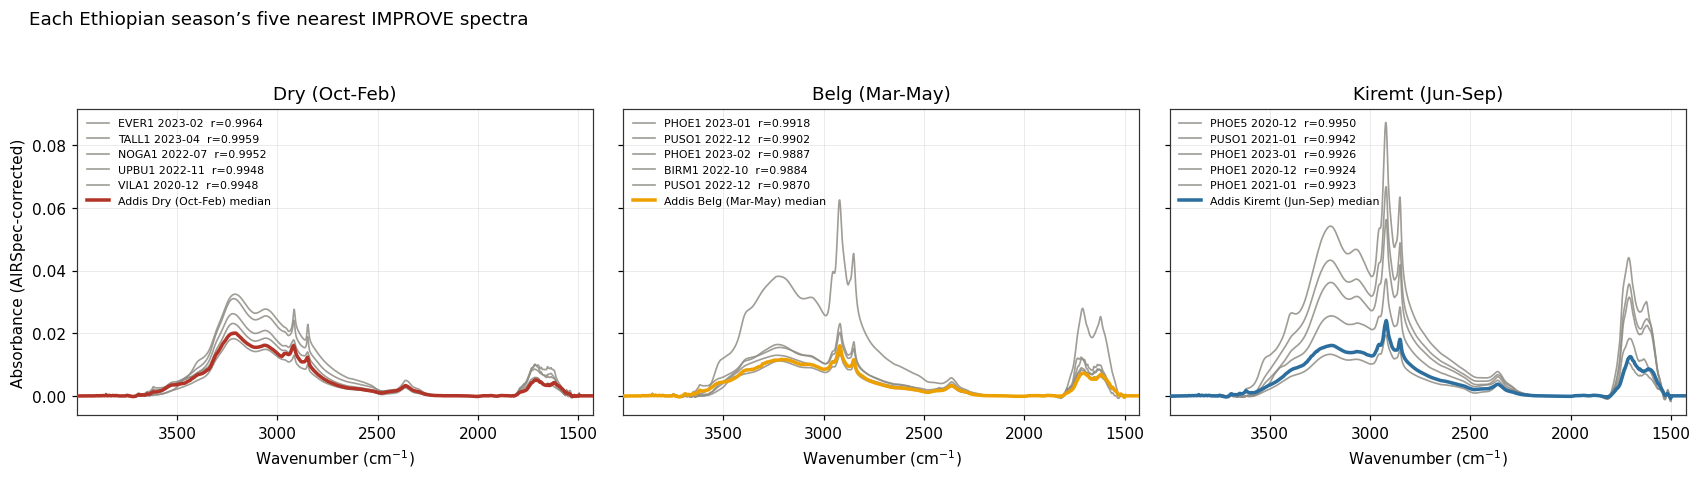

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.4), sharey=True)
for ax, name in zip(axes, SEASONS):
    sub = analogs_all[(analogs_all.season == name) & (analogs_all.search == 'all filters')]
    for _, row in sub.head(5).iterrows():
        li = int(np.where(lib.AnalysisId.to_numpy() == row.AnalysisId)[0][0])
        ax.plot(WN, LIB[li], lw=1.1, color='#8F8C84', alpha=0.85,
                label=f"{row.Site} {row.date[:7]}  r={row.r:.4f}")
    ax.plot(WN, season_median[name], lw=2.3, color=S_COLOUR[name], zorder=5,
            label=f'Addis {name} median')
    ax.set(xlim=(WN.max(), WN.min()), xlabel='Wavenumber (cm$^{-1}$)', title=name)
    ax.legend(frameon=False, fontsize=7.2, loc='upper left')
axes[0].set_ylabel('Absorbance (AIRSpec-corrected)')
fig.suptitle('Each Ethiopian season\u2019s five nearest IMPROVE spectra',
             x=0.02, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(PLOTS / 'season_top_analogs.png', dpi=150); plt.show()

The same question for Bishoftu is not answerable here: its 26 filters are all
dry-season, which is why it cannot arbitrate a seasonal claim on its own.

## Takeaways

1. **The network has a small number of spectral classes and the SPARTAN sites do not
   all land in the same ones** — see the per-target class distribution above. Where a
   target concentrates in one class, that class's IMPROVE membership *is* its analog
   population; where it spreads across classes, no single cohort will fit it.
2. **The top-level Ward split is deposit/SNR, not composition** (see the peak-absorbance
   column): low-loading spectra have noise-dominated standardized shapes and form their
   own classes. Any class read as chemistry has to be loading-conditioned first.
3. **Smoke-likeness is a proxy statement, and it has to survive loading.** There is no
   fire label in the database (the 36 fire-related comments do not intersect the pool),
   so smoke-lineage membership is the only handle, and the within-EC-bin enrichment
   table is what decides whether the enriched class means anything beyond "heavily
   loaded". Read that verdict line before calling anything a smoke class.
4. **Site similarity is answerable two ways and they should agree.** Median-spectrum r
   and class-mix distance are both reported; where they disagree, the site is
   heterogeneous and a single median misrepresents it.
6. **The network's own similarity structure survives baselining in rank but not in
   scale** (section 7): the raw and baselined site-similarity matrices agree in ordering
   while baselining spreads the whole network apart, because removing the shared
   PTFE/background leaves the real differences as a larger share of what remains. Where a
   site's nearest neighbour *changes*, its raw match was a background match.
7. **A match threshold, not a top-N — but validated on a task that can fail.**
   Same-class agreement is ~99% at any r here (k=4, one dominant class), so it cannot
   calibrate anything; "does the neighbour carry the same EC loading within 25%" can,
   and is what a calibration-usable match actually means. Quote that operating point.

Scope: lot-248/251 IMPROVE library, AIRSpec-corrected, 1425–3998 cm⁻¹. Classes are
spectral, not chemical identifications. The ward tree is one cut of one linkage; the
silhouette scan shows how flat that choice is.